# 03b. Normalización de chips y revisión del augmentation

Dos ajustes en el pipeline de imagen, medidos antes de proponerlos:

1. **Normalización.** `src/data/dataset.py` usa las constantes de ImageNet, calculadas sobre
   fotografías naturales. Los chips Sentinel-2 son mucho más oscuros, así que a la red le llega
   una señal descentrada y con poca amplitud.
2. **`ColorJitter`.** En teledetección el brillo absoluto es una medición física, no un
   accidente de iluminación. La hipótesis a contrastar es si el jitter está borrando esa
   señal. Se mide, y el resultado decide.

Este cuaderno **no modifica nada**: mide, justifica y deja las constantes y los `transforms`
listos para copiar. La decisión de aplicarlos a `src/` queda para después.

Todas las estadísticas se calculan **solo sobre `train`**, para no filtrar información de
`val` ni de `test`.

## 1. Configuración

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import roc_auc_score
from torchvision import transforms

# ── Rutas ──────────────────────────────────────────────────────────────────
DATA_RAW = Path("../data/01_raw")
DATA_MODEL_INPUT = Path("../data/05_model_input")
DATA_REPORTING = Path("../data/08_reporting")
FIGURES_DIR = Path("../reports/figures")

CHIPS_DIR = DATA_RAW / "dataset_amazonia_garimpo_binario"
MANIFEST_TRAIN = DATA_MODEL_INPUT / "manifest_train.csv"

# ── Parámetros ─────────────────────────────────────────────────────────────
SAMPLE_SIZE = 3000        # chips de train para medir (sube a 10000 si quieres más precisión)
RANDOM_STATE = 42
IMAGE_SIZE = 128

# Constantes actuales en src/data/dataset.py
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# ColorJitter actual en get_transforms("train")
JITTER_KWARGS = dict(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05)

CHANNELS = ("R (B4)", "G (B3)", "B (B2)")

DATA_REPORTING.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Chips dir : {CHIPS_DIR}  (existe: {CHIPS_DIR.exists()})")
print(f"Manifest  : {MANIFEST_TRAIN}  (existe: {MANIFEST_TRAIN.exists()})")

Chips dir : ..\data\01_raw\dataset_amazonia_garimpo_binario  (existe: True)
Manifest  : ..\data\05_model_input\manifest_train.csv  (existe: True)


## 2. Muestra de entrenamiento

Muestra estratificada por clase sobre `manifest_train.csv`. No se toca `val` ni `test`:
las constantes de normalización son un parámetro aprendido del conjunto de entrenamiento y
calcularlas con las otras particiones sería fuga.

In [2]:
train_manifest = pd.read_csv(MANIFEST_TRAIN)
print(f"Chips en train: {len(train_manifest):,}")
print(train_manifest["label_str"].value_counts().to_string())

muestra = (
    train_manifest.groupby("label_str", group_keys=False)
    .sample(n=SAMPLE_SIZE // 2, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)
print(f"\nMuestra: {len(muestra):,} chips "
      f"({muestra['label_str'].value_counts().to_dict()})")

Chips en train: 81,938
label_str
com_garimpo    45985
sem_garimpo    35953

Muestra: 3,000 chips ({'com_garimpo': 1500, 'sem_garimpo': 1500})


## 3. Recorrido único sobre la muestra

Una sola pasada acumula todo lo que hace falta:

- un **histograma exacto de 256 niveles por canal**, del que se derivan media, desviación y
  cualquier percentil sin guardar los píxeles en memoria,
- el **brillo medio de cada chip**, para medir la señal fotométrica,
- el **brillo del mismo chip tras aplicar `ColorJitter`**, para medir cuánto la degrada.

In [3]:
rng = np.random.default_rng(RANDOM_STATE)
# ColorJitter usa el RNG global de torch: hay que fijarlo o el resultado no es reproducible
torch.manual_seed(RANDOM_STATE)
jitter = transforms.ColorJitter(**JITTER_KWARGS)

hist = np.zeros((3, 256), dtype=np.int64)
brillo_raw: list[float] = []
brillo_jit: list[float] = []

for png_path in muestra["png_path"]:
    with Image.open(CHIPS_DIR / png_path) as img:
        rgb = img.convert("RGB")
        arr = np.asarray(rgb)
        arr_jit = np.asarray(jitter(rgb))

    for c in range(3):
        hist[c] += np.bincount(arr[..., c].ravel(), minlength=256)

    brillo_raw.append(float(arr.mean()) / 255.0)
    brillo_jit.append(float(arr_jit.mean()) / 255.0)

muestra["brillo_raw"] = brillo_raw
muestra["brillo_jit"] = brillo_jit

n_px = hist[0].sum()
print(f"Píxeles acumulados por canal: {n_px:,}")
print(f"Chips procesados            : {len(muestra):,}")

Píxeles acumulados por canal: 49,152,000
Chips procesados            : 3,000


## 4. Estadísticas reales por canal

Media y desviación se calculan de forma **exacta** a partir del histograma, no por muestreo:

\[
\mu = \frac{1}{N}\sum_{v=0}^{255} v \cdot h_v
\qquad
\sigma = \sqrt{\frac{1}{N}\sum_{v=0}^{255} v^2 h_v - \mu^2}
\]

In [4]:
niveles = np.arange(256, dtype=np.float64)


def stats_desde_histograma(h: np.ndarray) -> tuple[float, float]:
    """Media y desviación exactas (escala 0-1) a partir de un histograma de 256 niveles."""
    n = h.sum()
    media = float((niveles * h).sum() / n)
    var = float((niveles ** 2 * h).sum() / n) - media ** 2
    return media / 255.0, np.sqrt(max(var, 0.0)) / 255.0


def percentil_desde_histograma(h: np.ndarray, q: float) -> float:
    """Percentil q (0-100) en escala 0-1 a partir del histograma."""
    acumulado = np.cumsum(h) / h.sum()
    return float(np.searchsorted(acumulado, q / 100.0)) / 255.0


filas = []
for c, nombre in enumerate(CHANNELS):
    media, desv = stats_desde_histograma(hist[c])
    filas.append({
        "canal": nombre,
        "media": round(media, 4),
        "desv": round(desv, 4),
        "p1": round(percentil_desde_histograma(hist[c], 1), 4),
        "p50": round(percentil_desde_histograma(hist[c], 50), 4),
        "p99": round(percentil_desde_histograma(hist[c], 99), 4),
        "imagenet_media": IMAGENET_MEAN[c],
        "imagenet_desv": IMAGENET_STD[c],
    })

stats = pd.DataFrame(filas)
display(stats)

DATASET_MEAN = tuple(round(stats_desde_histograma(hist[c])[0], 4) for c in range(3))
DATASET_STD = tuple(round(stats_desde_histograma(hist[c])[1], 4) for c in range(3))
P1 = tuple(round(percentil_desde_histograma(hist[c], 1), 4) for c in range(3))
P99 = tuple(round(percentil_desde_histograma(hist[c], 99), 4) for c in range(3))

print(f"DATASET_MEAN = {DATASET_MEAN}")
print(f"DATASET_STD  = {DATASET_STD}")
print(f"P1           = {P1}")
print(f"P99          = {P99}")

,canal,media,desv,p1,p50,p99,imagenet_media,imagenet_desv
0,R (B4),0.0303,0.0831,0.0000,0.0039,0.4235,0.485,0.229
1,G (B3),0.0813,0.0541,0.0039,0.0706,0.2980,0.456,0.224
2,B (B2),0.0202,0.0382,0.0000,0.0078,0.1882,0.406,0.225


DATASET_MEAN = (0.0303, 0.0813, 0.0202)
DATASET_STD  = (np.float64(0.0831), np.float64(0.0541), np.float64(0.0382))
P1           = (0.0, 0.0039, 0.0)
P99          = (0.4235, 0.298, 0.1882)


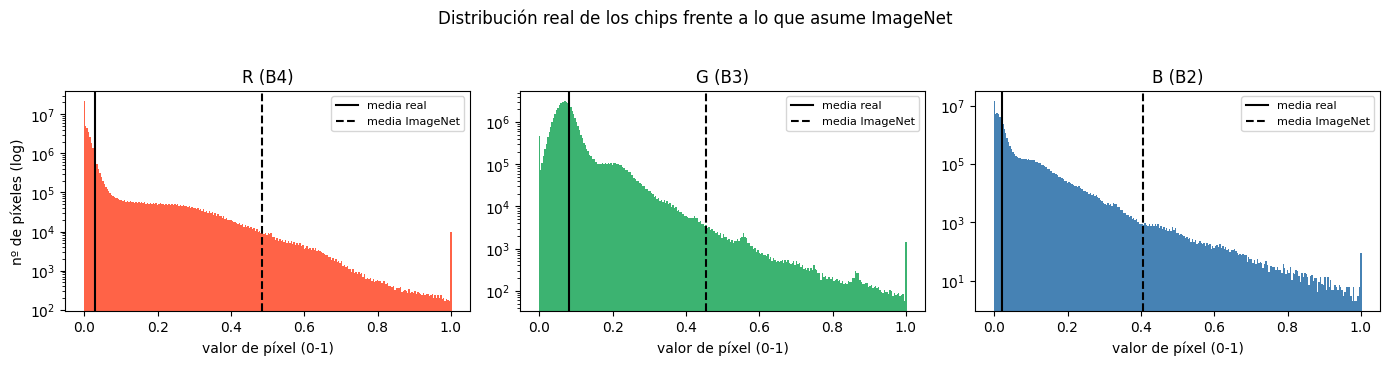

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
colores = ["tomato", "mediumseagreen", "steelblue"]

for c, (ax, nombre) in enumerate(zip(axes, CHANNELS)):
    ax.bar(niveles / 255.0, hist[c], width=1 / 255.0, color=colores[c])
    ax.axvline(DATASET_MEAN[c], color="black", ls="-", lw=1.5, label="media real")
    ax.axvline(IMAGENET_MEAN[c], color="black", ls="--", lw=1.5, label="media ImageNet")
    ax.set_yscale("log")
    ax.set_xlabel("valor de píxel (0-1)")
    ax.set_title(nombre)
    ax.legend(fontsize=8)

axes[0].set_ylabel("nº de píxeles (log)")
plt.suptitle("Distribución real de los chips frente a lo que asume ImageNet", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "norm_histogramas_canal.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Qué le llega realmente a la red

El objetivo de normalizar es que la entrada tenga media ≈ 0 y desviación ≈ 1, que es el régimen
para el que se calibraron los pesos preentrenados. Comparamos las tres opciones sobre el mismo
histograma.

In [6]:
def resumen_normalizacion(h: np.ndarray, media: float, desv: float) -> tuple[float, float]:
    """Media y desviación resultantes tras aplicar (x - media) / desv."""
    mu, sigma = stats_desde_histograma(h)
    return (mu - media) / desv, sigma / desv


filas = []
for etiqueta, medias, desvs in [
    ("ImageNet (actual)", IMAGENET_MEAN, IMAGENET_STD),
    ("Estadísticas propias", DATASET_MEAN, DATASET_STD),
]:
    for c, nombre in enumerate(CHANNELS):
        mu_out, sd_out = resumen_normalizacion(hist[c], medias[c], desvs[c])
        filas.append({"normalización": etiqueta, "canal": nombre,
                      "media_resultante": round(mu_out, 3),
                      "desv_resultante": round(sd_out, 3)})

comparativa = pd.DataFrame(filas).pivot(
    index="canal", columns="normalización", values=["media_resultante", "desv_resultante"]
)
display(comparativa)

print("Objetivo: media ≈ 0.0 y desviación ≈ 1.0 en cada canal.")
print("\nCon ImageNet la entrada queda desplazada muy por debajo de cero y con una")
print("amplitud mucho menor que la esperada: la red recibe una señal comprimida.")

media_resultante                        desv_resultante  \
normalización Estadísticas propias ImageNet (actual) Estadísticas propias   
canal                                                                       
B (B2)                      -0.001            -1.715                1.000   
G (B3)                       0.000            -1.673                1.001   
R (B4)                       0.000            -1.985                1.000   

                                 
normalización ImageNet (actual)  
canal                            
B (B2)                    0.170  
G (B3)                    0.242  
R (B4)                    0.363

Objetivo: media ≈ 0.0 y desviación ≈ 1.0 en cada canal.

Con ImageNet la entrada queda desplazada muy por debajo de cero y con una
amplitud mucho menor que la esperada: la red recibe una señal comprimida.


## 6. El rango dinámico desperdiciado

Además del centrado, hay un problema de escala: casi todos los píxeles se concentran en la
parte baja del rango. Esto ocurrió al convertir los `.tif` a PNG y **no se recupera con
normalización**; solo se arregla regenerando los PNG. Se mide aquí para dejar constancia.

In [7]:
gris = hist.sum(axis=0)
acumulado = np.cumsum(gris) / gris.sum()

for umbral in (0.05, 0.10, 0.20, 0.50):
    idx = int(umbral * 255)
    print(f"  % de píxeles por debajo de {umbral:.2f}: {acumulado[idx] * 100:5.1f} %")

niveles_utiles = int((gris[: int(0.20 * 255)] > 0).sum())
print(f"\nNiveles distintos usados por debajo de 0.20: {niveles_utiles} de 51 posibles")
print(f"Rango p1-p99 por canal:")
for c, nombre in enumerate(CHANNELS):
    print(f"  {nombre}: [{P1[c]:.4f}, {P99[c]:.4f}]  -> usa el "
          f"{(P99[c] - P1[c]) * 100:.1f} % del rango disponible")

  % de píxeles por debajo de 0.05:  66.0 %
  % de píxeles por debajo de 0.10:  90.1 %
  % de píxeles por debajo de 0.20:  96.6 %
  % de píxeles por debajo de 0.50:  99.8 %

Niveles distintos usados por debajo de 0.20: 51 de 51 posibles
Rango p1-p99 por canal:
  R (B4): [0.0000, 0.4235]  -> usa el 42.4 % del rango disponible
  G (B3): [0.0039, 0.2980]  -> usa el 29.4 % del rango disponible
  B (B2): [0.0000, 0.1882]  -> usa el 18.8 % del rango disponible


## 7. Cuánta señal hay en el brillo

Las zonas de garimpo son suelo expuesto y agua con sedimento: brillantes. El bosque es oscuro.
Si eso es cierto, el **brillo medio por sí solo** debería separar las clases bastante por encima
del azar. Lo medimos con el AUC, que es exactamente la probabilidad de que un chip con minería
tomado al azar tenga más brillo que uno sin minería.

AUC usando SOLO el brillo medio: 0.5884   (0.5 = azar)

Brillo medio por clase:
               mean     std
label_str                  
com_garimpo  0.0548  0.0529
sem_garimpo  0.0331  0.0171


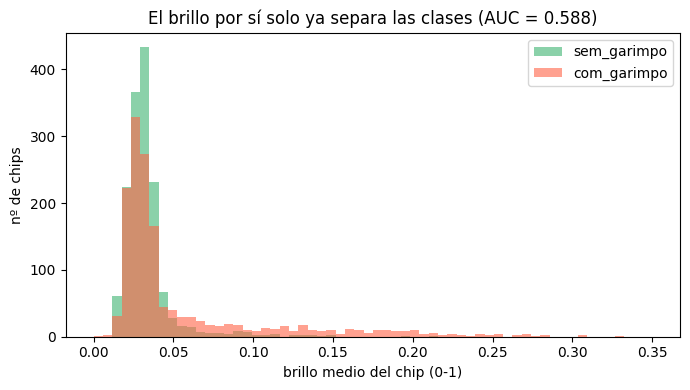

In [8]:
y = muestra["label_int"].to_numpy()
auc_raw = roc_auc_score(y, muestra["brillo_raw"])

print(f"AUC usando SOLO el brillo medio: {auc_raw:.4f}   (0.5 = azar)")
print("\nBrillo medio por clase:")
print(muestra.groupby("label_str")["brillo_raw"].agg(["mean", "std"]).round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
for etiqueta, color in [("sem_garimpo", "mediumseagreen"), ("com_garimpo", "tomato")]:
    sub = muestra.loc[muestra["label_str"] == etiqueta, "brillo_raw"]
    ax.hist(sub, bins=60, alpha=0.6, label=etiqueta, color=color, range=(0, 0.35))

ax.set_xlabel("brillo medio del chip (0-1)")
ax.set_ylabel("nº de chips")
ax.set_title(f"El brillo por sí solo ya separa las clases (AUC = {auc_raw:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "norm_brillo_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. ¿Degrada el `ColorJitter` esa señal?

Mismos chips, mismo brillo medido, pero después de pasar por
`ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05)`.

La hipótesis de partida era que el jitter, al mover el brillo al azar, borraría parte de la
señal y el AUC bajaría. Para no quedarnos en la impresión, la diferencia se acompaña de un
**intervalo de confianza por bootstrap emparejado**: si el intervalo contiene el cero, la
diferencia es ruido y la hipótesis no se sostiene.

AUC del brillo sin jitter : 0.5884
AUC del brillo con jitter : 0.5923
Diferencia (sin - con)    : -0.0038


IC 95 % de la diferencia  : [-0.0120, +0.0052]

Veredicto: la diferencia NO es distinguible de cero: el jitter no degrada la señal de forma medible

Correlación brillo original vs perturbado: 0.9826
Desplazamiento medio del brillo          : 0.0053 (12.0 % del brillo medio)


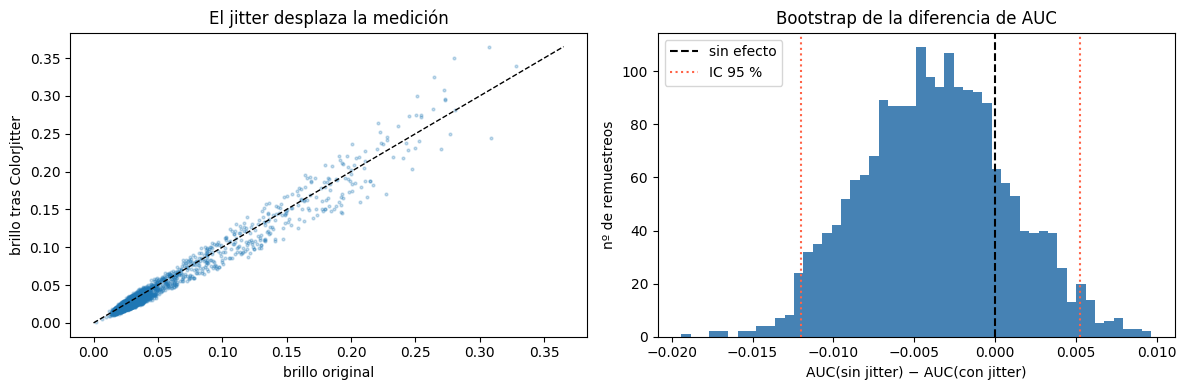

In [9]:
auc_jit = roc_auc_score(y, muestra["brillo_jit"])
caida = auc_raw - auc_jit

print(f"AUC del brillo sin jitter : {auc_raw:.4f}")
print(f"AUC del brillo con jitter : {auc_jit:.4f}")
print(f"Diferencia (sin - con)    : {caida:+.4f}")

# ── Bootstrap emparejado sobre la diferencia de AUC ────────────────────────
N_BOOT = 2000
b_raw = muestra["brillo_raw"].to_numpy()
b_jit = muestra["brillo_jit"].to_numpy()
diffs = np.empty(N_BOOT)

for i in range(N_BOOT):
    idx = rng.integers(0, len(y), len(y))
    if len(np.unique(y[idx])) < 2:
        diffs[i] = np.nan
        continue
    diffs[i] = roc_auc_score(y[idx], b_raw[idx]) - roc_auc_score(y[idx], b_jit[idx])

lo, hi = np.nanpercentile(diffs, [2.5, 97.5])
print(f"IC 95 % de la diferencia  : [{lo:+.4f}, {hi:+.4f}]")

if lo > 0:
    veredicto = "el jitter SÍ degrada la señal fotométrica de forma medible"
elif hi < 0:
    veredicto = "el jitter no degrada la señal (incluso la ordena algo mejor)"
else:
    veredicto = ("la diferencia NO es distinguible de cero: el jitter no degrada "
                 "la señal de forma medible")
print(f"\nVeredicto: {veredicto}")

corr = muestra["brillo_raw"].corr(muestra["brillo_jit"])
desvio = (muestra["brillo_jit"] - muestra["brillo_raw"]).abs().mean()
print(f"\nCorrelación brillo original vs perturbado: {corr:.4f}")
print(f"Desplazamiento medio del brillo          : {desvio:.4f} "
      f"({desvio / muestra['brillo_raw'].mean() * 100:.1f} % del brillo medio)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(muestra["brillo_raw"], muestra["brillo_jit"], s=4, alpha=0.25)
lim = float(muestra[["brillo_raw", "brillo_jit"]].to_numpy().max())
axes[0].plot([0, lim], [0, lim], "k--", lw=1)
axes[0].set_xlabel("brillo original")
axes[0].set_ylabel("brillo tras ColorJitter")
axes[0].set_title("El jitter desplaza la medición")

axes[1].hist(diffs[~np.isnan(diffs)], bins=50, color="steelblue")
axes[1].axvline(0, color="black", ls="--", lw=1.5, label="sin efecto")
axes[1].axvline(lo, color="tomato", ls=":", lw=1.5)
axes[1].axvline(hi, color="tomato", ls=":", lw=1.5, label="IC 95 %")
axes[1].set_xlabel("AUC(sin jitter) − AUC(con jitter)")
axes[1].set_ylabel("nº de remuestreos")
axes[1].set_title("Bootstrap de la diferencia de AUC")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "norm_colorjitter_efecto.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Comparación visual

Los mismos chips con la normalización actual y con la propuesta. El *stretch* por percentiles
usa un rango fijo calculado sobre `train`, **igual para todas las imágenes**: así el bosque
sigue siendo oscuro y la minería sigue siendo brillante. Un auto-contraste por imagen haría lo
contrario y borraría justamente la diferencia entre clases.

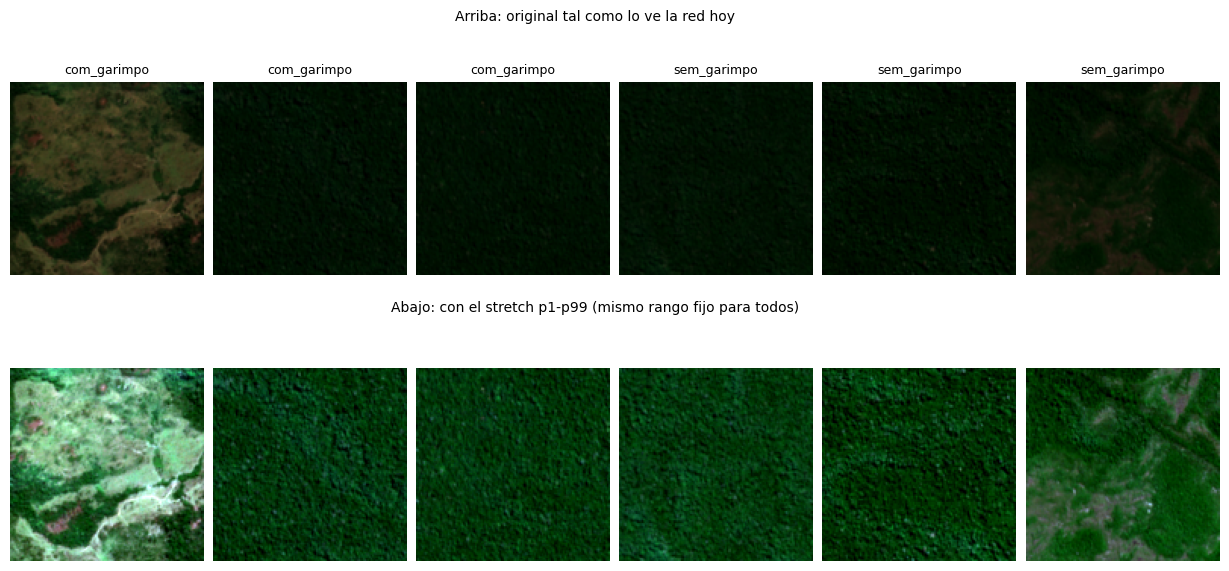

In [10]:
def stretch_percentil(arr: np.ndarray, p1: tuple, p99: tuple) -> np.ndarray:
    """Estira cada canal al rango [p1, p99] fijo. Mismo estiramiento para todas las imágenes."""
    salida = np.empty_like(arr, dtype=np.float32)
    for c in range(3):
        salida[..., c] = np.clip((arr[..., c] - p1[c]) / (p99[c] - p1[c]), 0.0, 1.0)
    return salida


ejemplos = pd.concat([
    muestra[muestra["label_str"] == "com_garimpo"].head(3),
    muestra[muestra["label_str"] == "sem_garimpo"].head(3),
])

fig, axes = plt.subplots(2, len(ejemplos), figsize=(2.6 * len(ejemplos), 6.2))
for j, (_, fila) in enumerate(ejemplos.iterrows()):
    with Image.open(CHIPS_DIR / fila["png_path"]) as img:
        arr = np.asarray(img.convert("RGB")).astype(np.float32) / 255.0

    axes[0, j].imshow(arr)
    axes[0, j].set_title(fila["label_str"], fontsize=9)
    axes[1, j].imshow(stretch_percentil(arr, P1, P99))
    for i in (0, 1):
        axes[i, j].axis("off")

axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("stretch")
fig.text(0.5, 0.945, "Arriba: original tal como lo ve la red hoy", ha="center", fontsize=10)
fig.text(0.5, 0.475, "Abajo: con el stretch p1-p99 (mismo rango fijo para todos)",
         ha="center", fontsize=10)
fig.subplots_adjust(top=0.90, bottom=0.02, hspace=0.10, wspace=0.05)
plt.savefig(FIGURES_DIR / "norm_comparacion_visual.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ¿El stretch conserva la separación entre clases? (debe conservarla, es lineal y fijo)
brillo_stretch = []
for png_path in ejemplos["png_path"]:
    with Image.open(CHIPS_DIR / png_path) as img:
        arr = np.asarray(img.convert("RGB")).astype(np.float32) / 255.0
    brillo_stretch.append(stretch_percentil(arr, P1, P99).mean())

for (_, fila), b in zip(ejemplos.iterrows(), brillo_stretch):
    print(f"  {fila['label_str']:<12} brillo original {fila['brillo_raw']:.4f} "
          f"-> tras stretch {b:.4f}")

print("\nEl orden entre clases se conserva: el stretch reescala, no iguala.")

  com_garimpo  brillo original 0.1327 -> tras stretch 0.4418
  com_garimpo  brillo original 0.0263 -> tras stretch 0.0898
  com_garimpo  brillo original 0.0250 -> tras stretch 0.0841
  sem_garimpo  brillo original 0.0285 -> tras stretch 0.0968
  sem_garimpo  brillo original 0.0234 -> tras stretch 0.0768
  sem_garimpo  brillo original 0.0458 -> tras stretch 0.1499

El orden entre clases se conserva: el stretch reescala, no iguala.


## 10. Transforms propuestas

Listas para copiar. Se dejan aquí, **sin modificar `src/data/dataset.py`**, para que la decisión
de adoptarlas sea explícita.

El único cambio que la medición respalda es la **normalización**. El `ColorJitter` queda como
parámetro (`color_jitter=True` por defecto, igual que ahora) porque la sección 8 no encontró
evidencia de que esté haciendo daño. Si se quiere probar sin él, que sea como ablación
controlada, no como corrección de un problema demostrado.

In [12]:
def get_transforms_v2(
    split: str,
    usar_stretch: bool = False,
    color_jitter: bool = True,
) -> transforms.Compose:
    """
    Transforms con normalización medida sobre train.

    ``usar_stretch=True`` aplica el estiramiento p1-p99 antes de normalizar; en ese caso
    la normalización usa ImageNet, porque tras el stretch el rango ya es comparable al de
    una imagen natural.

    ``color_jitter`` se deja en True (comportamiento actual): la sección 8 no encontró
    evidencia de que degrade la señal. Ponerlo en False sirve para ablación.
    """
    pasos: list = []

    if usar_stretch:
        pasos.append(transforms.Lambda(
            lambda img: Image.fromarray(
                (stretch_percentil(np.asarray(img).astype(np.float32) / 255.0, P1, P99)
                 * 255).astype(np.uint8)
            )
        ))
        media, desv = IMAGENET_MEAN, IMAGENET_STD
    else:
        media, desv = DATASET_MEAN, DATASET_STD

    if split == "train":
        pasos += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=90),
        ]
        if color_jitter:
            pasos.append(transforms.ColorJitter(**JITTER_KWARGS))

    pasos += [transforms.ToTensor(), transforms.Normalize(mean=media, std=desv)]
    return transforms.Compose(pasos)


# Verificación rápida sobre un chip real
with Image.open(CHIPS_DIR / muestra["png_path"].iloc[0]) as img:
    chip = img.convert("RGB")

for etiqueta, tf in [
    ("actual (ImageNet + jitter)",
     transforms.Compose([transforms.ToTensor(),
                         transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])),
    ("propuesta (stats propias)", get_transforms_v2("val")),
    ("propuesta (stretch p1-p99)", get_transforms_v2("val", usar_stretch=True)),
]:
    t = tf(chip)
    print(f"  {etiqueta:<28} media {t.mean():+.3f}  desv {t.std():.3f}  "
          f"rango [{t.min():+.2f}, {t.max():+.2f}]")

  actual (ImageNet + jitter)   media -1.399  desv 0.310  rango [-2.12, -0.17]
  propuesta (stats propias)    media +1.519  desv 1.118  rango [-1.43, +6.04]
  propuesta (stretch p1-p99)   media -0.036  desv 1.045  rango [-2.12, +2.64]


## 11. Exportar las constantes

In [13]:
constantes = {
    "calculado_sobre": "manifest_train.csv",
    "n_chips_muestreados": int(len(muestra)),
    "random_state": RANDOM_STATE,
    "DATASET_MEAN": list(DATASET_MEAN),
    "DATASET_STD": list(DATASET_STD),
    "P1": list(P1),
    "P99": list(P99),
    "auc_brillo_sin_jitter": round(float(auc_raw), 4),
    "auc_brillo_con_jitter": round(float(auc_jit), 4),
    "auc_diff_ic95": [round(float(lo), 4), round(float(hi), 4)],
    "veredicto_colorjitter": veredicto,
}

OUT_JSON = DATA_REPORTING / "normalization_constants.json"
OUT_JSON.write_text(json.dumps(constantes, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Guardado: {OUT_JSON}\n")
print(json.dumps(constantes, indent=2, ensure_ascii=False))

stats.to_csv(DATA_REPORTING / "normalization_channel_stats.csv", index=False)
print(f"\nGuardado: {DATA_REPORTING / 'normalization_channel_stats.csv'}")

Guardado: ..\data\08_reporting\normalization_constants.json

{
  "calculado_sobre": "manifest_train.csv",
  "n_chips_muestreados": 3000,
  "random_state": 42,
  "DATASET_MEAN": [
    0.0303,
    0.0813,
    0.0202
  ],
  "DATASET_STD": [
    0.0831,
    0.0541,
    0.0382
  ],
  "P1": [
    0.0,
    0.0039,
    0.0
  ],
  "P99": [
    0.4235,
    0.298,
    0.1882
  ],
  "auc_brillo_sin_jitter": 0.5884,
  "auc_brillo_con_jitter": 0.5923,
  "auc_diff_ic95": [
    -0.012,
    0.0052
  ],
  "veredicto_colorjitter": "la diferencia NO es distinguible de cero: el jitter no degrada la señal de forma medible"
}

Guardado: ..\data\08_reporting\normalization_channel_stats.csv


### Para aplicarlo en `src/data/dataset.py`

Cuando se decida adoptarlo, el cambio es **una sola cosa**: sustituir las dos constantes de
normalización. El resto de `get_transforms()` se queda como está.

```python
# Constantes medidas sobre train (ver 03b_normalizacion_chips.ipynb)
DATASET_MEAN = (...)   # el valor impreso arriba
DATASET_STD = (...)

def get_transforms(split: str) -> transforms.Compose:
    normalize = transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
    ...   # sin más cambios
```

Importante: si se cambia la normalización, **los checkpoints actuales dejan de ser válidos**.
Fueron entrenados con la escala de ImageNet y hay que reentrenar para comparar de forma justa.

## 12. Conclusiones

In [14]:
print("═══ Resumen ═══\n")
print("1. NORMALIZACIÓN")
for c, nombre in enumerate(CHANNELS):
    mu_im, sd_im = resumen_normalizacion(hist[c], IMAGENET_MEAN[c], IMAGENET_STD[c])
    mu_ds, sd_ds = resumen_normalizacion(hist[c], DATASET_MEAN[c], DATASET_STD[c])
    print(f"   {nombre}: ImageNet -> media {mu_im:+.2f} desv {sd_im:.2f}   |   "
          f"propias -> media {mu_ds:+.2f} desv {sd_ds:.2f}")

print(f"\n2. COLORJITTER")
print(f"   Brillo solo: AUC {auc_raw:.4f} sin jitter, {auc_jit:.4f} con jitter.")
print(f"   IC 95 % de la diferencia: [{lo:+.4f}, {hi:+.4f}]")
print(f"   -> {veredicto}.")
print(f"   NO se propone quitarlo: la hipótesis inicial no se confirmó.")

print(f"\n3. LÍMITE NO RECUPERABLE")
print(f"   El {acumulado[int(0.10 * 255)] * 100:.0f} % de los píxeles está por debajo de 0.10.")
print(f"   Esa pérdida de precisión ocurrió al exportar los PNG y solo se")
print(f"   arregla regenerándolos desde los .tif originales.")

═══ Resumen ═══

1. NORMALIZACIÓN
   R (B4): ImageNet -> media -1.99 desv 0.36   |   propias -> media +0.00 desv 1.00
   G (B3): ImageNet -> media -1.67 desv 0.24   |   propias -> media +0.00 desv 1.00
   B (B2): ImageNet -> media -1.71 desv 0.17   |   propias -> media -0.00 desv 1.00

2. COLORJITTER
   Brillo solo: AUC 0.5884 sin jitter, 0.5923 con jitter.
   IC 95 % de la diferencia: [-0.0120, +0.0052]
   -> la diferencia NO es distinguible de cero: el jitter no degrada la señal de forma medible.
   NO se propone quitarlo: la hipótesis inicial no se confirmó.

3. LÍMITE NO RECUPERABLE
   El 90 % de los píxeles está por debajo de 0.10.
   Esa pérdida de precisión ocurrió al exportar los PNG y solo se
   arregla regenerándolos desde los .tif originales.


De las dos hipótesis con las que empezó este cuaderno, **una se confirmó y la otra no.**

La **normalización sí es un problema real**. Con las constantes de ImageNet la entrada llega
descentrada muy por debajo de cero y con una amplitud mucho menor que la esperada; con las
medidas sobre `train` llega centrada y con desviación unidad, que es el régimen para el que se
entrenaron los pesos. En ResNet-50 y EfficientNet-B0 el BatchNorm compensa parte del problema
por su cuenta, así que la mejora será moderada; en ViT y Swin, que no tienen esa compensación,
debería notarse más. Este es el cambio que vale la pena hacer.

El **`ColorJitter` no resultó ser el problema que se sospechaba**. La hipótesis era que, al
mover el brillo al azar, borraría una señal que separa las clases. La medición no la sostiene:
la diferencia de AUC entre el brillo original y el perturbado no se distingue de cero. Además
la señal fotométrica dentro de `train` es más débil de lo que sugería una muestra global
(las teselas de `test` tienen un contraste entre clases mucho mayor, y eso inflaba la
estimación). Conclusión: dejarlo como está. Si se quiere probar sin él, que sea como ablación
medida, no como corrección.

Queda un techo que ninguno de estos cambios toca: la conversión a PNG ya comprimió la
reflectancia en la parte baja del rango, y esa precisión no se recupera con ninguna
normalización. Si en algún momento se regeneran los chips desde los `.tif`, conviene aplicar el
estiramiento **antes** de guardar el PNG.

Como este cuaderno no modifica `src/`, el entrenamiento sigue usando las constantes de ImageNet
hasta que se decida lo contrario.